# Euclidean VAE

In [187]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [188]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [189]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.euclidean_vae as model
import lib.trainer as trainer
import lib.utils as utils



### Set up and initialize data loader

In [190]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

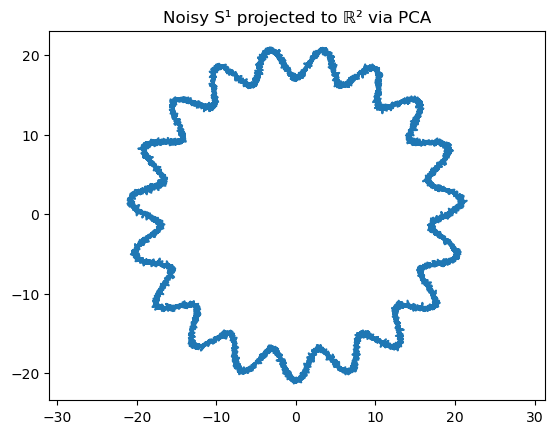

In [191]:
batch_size = 64

loader_config = {"dataset_name": "s1_synthetic",
                 "batch_size": 128,
                 "synthetic_rotation": "random",
                 "n_times": 10000,
                 "radius": 19.0,
                 "n_wiggles": 19,
                 "geodesic_distortion_amp": 0.1,
                 "embedding_dim": 10,
                 "noise_var": 0.0001,
                 "geodesic_distortion_func": "wiggles",
                 "plot_dataset": True}

dataloader = dataloader.load_synthetic_ds(loader_config)
train_loader, test_loader = dataloader


### Model

In [192]:
data_dim = loader_config["embedding_dim"]
latent_dim = 2
sftbeta = 1
device = "cpu"
encoder_width = 5
encoder_depth = 2
decoder_width = 5
decoder_depth = 2

model_config = {'data_dim': data_dim, 'latent_dim': latent_dim, 'sftbeta': sftbeta, 'device': device,
                'encoder_width': encoder_width, 'encoder_depth': encoder_depth, 'decoder_width': decoder_width,
                'decoder_depth': decoder_depth}

euclidean_model = model.EuclideanVAE(model_config)

### Optimizer

In [193]:
learning_rate = 0.001

euclidean_optimizer = optim.Adam(euclidean_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [194]:
num_epochs = 15
log_interval = 100
device = "cpu"
recon_loss = "MSE"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'recon_loss': recon_loss, 'device': device}

euclidean_history = trainer.MVAETrainer(euclidean_model, dataloader, euclidean_optimizer, trainer_config).train()

Trainer successfully initialized.
Training the gaussianVAE model.
Starting epoch 1/15
Epoch 1/15, Train Loss: 365.4296, Test Loss: 363.4013
--------------------------------------------------
Starting epoch 2/15
Epoch 2/15, Train Loss: 362.6202, Test Loss: 356.6988
--------------------------------------------------
Starting epoch 3/15
Epoch 3/15, Train Loss: 353.9100, Test Loss: 348.9532
--------------------------------------------------
Starting epoch 4/15
Epoch 4/15, Train Loss: 349.3910, Test Loss: 346.0614
--------------------------------------------------
Starting epoch 5/15
Epoch 5/15, Train Loss: 346.6071, Test Loss: 343.3294
--------------------------------------------------
Starting epoch 6/15
Epoch 6/15, Train Loss: 343.8362, Test Loss: 340.6020
--------------------------------------------------
Starting epoch 7/15
Epoch 7/15, Train Loss: 341.0460, Test Loss: 337.8046
--------------------------------------------------
Starting epoch 8/15
Epoch 8/15, Train Loss: 338.7032, Test 

### Plot history

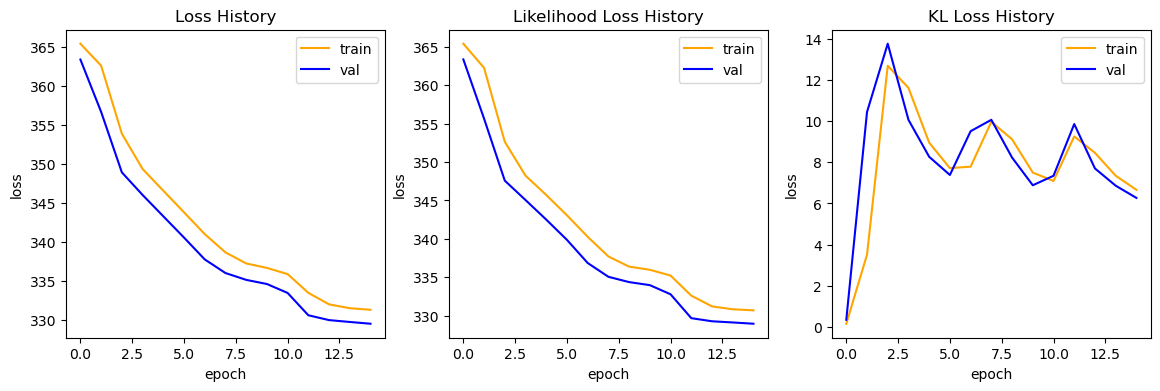

In [195]:
utils.show_training_history(euclidean_history)

### Save trained models

In [196]:
#modelutils.save_model(euclidean_model, model_config, "8dimLS")

#### Load pretrained models

In [197]:
#model = modelutils.load_model("gaussian_test1740071726")
#model = euclidean_model

### Visualizing the latent space

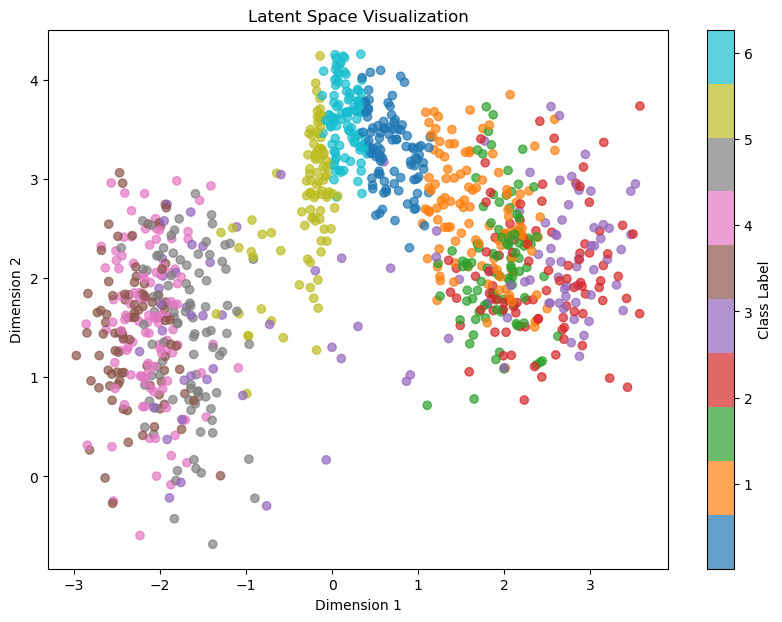

In [198]:
utils.plot_euclidean_latent_space(euclidean_model, test_loader, n_samples=5000)

#### Visualize reconstructed mnist images